```{contents}
```

# Intiutions

## **1. The Problem PCA Solves**

Imagine you have a dataset with multiple features (dimensions). High-dimensional data can be:

* Hard to visualize
* Redundant (features correlated)
* Noisy

**Goal:** Find a smaller set of new axes (directions) that capture most of the important information (variance) in the data.

---

## **2. The Core Idea**

PCA finds **new axes (principal components)** that:

1. Are linear combinations of the original features.
2. Are **orthogonal** (uncorrelated) to each other.
3. Capture the **maximum variance** along the first axis, then the next maximum along the second, and so on.

💡 Intuition: “Reorient the data along directions where it spreads out the most.”

---

## **3. Geometric Intuition**

* Imagine a 2D cloud of points (like a blob).
* You want to fit a straight line that best “summarizes” the blob.
* **Step 1:** Find the direction along which the cloud is most stretched → **First principal component (PC1)**
* **Step 2:** Find a perpendicular direction that captures the next largest spread → **Second principal component (PC2)**

In 3D, think of fitting a plane first (PC1 + PC2), then the remaining dimension captures minimal variance (PC3).

> PCA is like finding the **axes of an ellipsoid** that best fit your data.

---

## **4. Variance and Information**

PCA assumes:

* Directions with **high variance** carry the most “information.”
* Directions with low variance might just be noise.

So by keeping only the top few principal components, we **compress the data** while keeping most of the important patterns.

---

## **5. Algebraic Intuition**

1. Center the data around 0.
2. Compute the **covariance matrix** → captures relationships between features.
3. Find **eigenvectors** of the covariance matrix → these are the principal components (directions).
4. Eigenvalues → tell you **how much variance** is captured by each component.

> Intuition: Eigenvectors are the “best-fit axes,” eigenvalues are the “stretchiness” along each axis.

---

## **6. Dimensionality Reduction**

* Suppose original data has 10 features.
* If 90% of variance is captured in the first 2 PCs, you can represent the data in 2D instead of 10D.
* You’ve **reduced dimensionality** without losing much information.

---

## **7. Visual Analogy**

Imagine shining a flashlight on a 3D object:

* The **shadow** on a wall captures most of the shape in 2D.
* PCA is like finding the **best wall** to cast that shadow.

---

**Key Takeaways**

* PCA = Reorient data along directions of maximal spread.
* First PC = direction of highest variance.
* Next PCs = orthogonal directions of decreasing variance.
* PCA = compress data → reduce noise and redundancy.



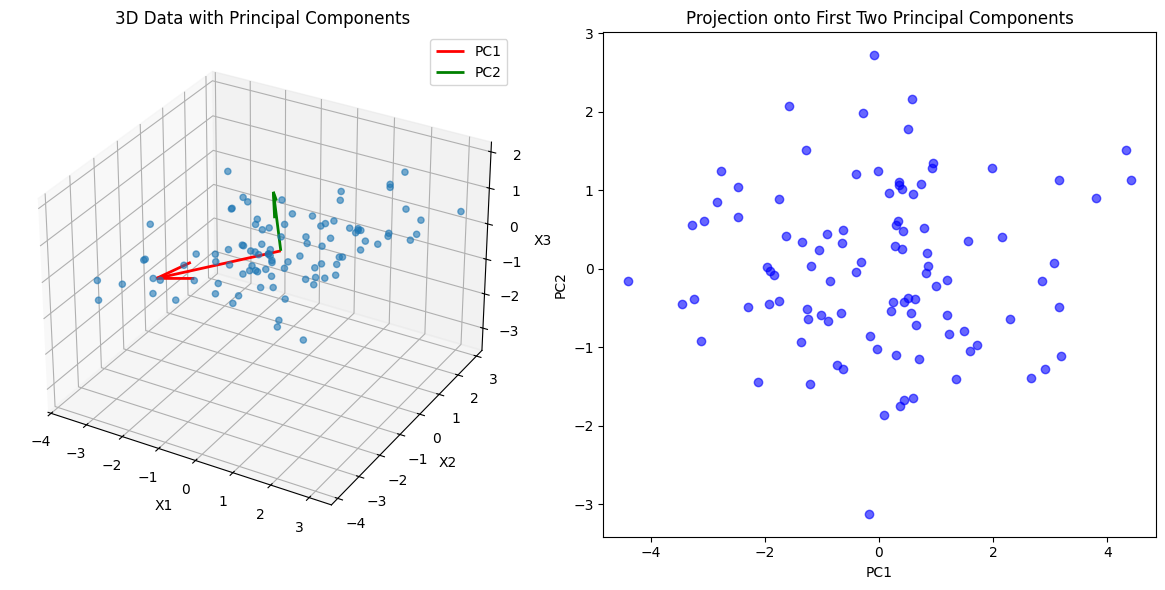

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Generate sample 3D data
np.random.seed(42)
n_samples = 100
mean = [0, 0, 0]
cov = [[3, 2, 0.5],
       [2, 2, 0],
       [0.5, 0, 1]]
X = np.random.multivariate_normal(mean, cov, n_samples)

# Compute PCA
X_meaned = X - np.mean(X, axis=0)
cov_matrix = np.cov(X_meaned.T)
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
idx = np.argsort(eigenvalues)[::-1]
eigenvectors = eigenvectors[:, idx]
eigenvalues = eigenvalues[idx]

# Top 2 components for projection
W = eigenvectors[:, :2]
X_pca = X_meaned.dot(W)

# Plot 3D scatter and PCA vectors
fig = plt.figure(figsize=(12,6))

# 3D Scatter
ax = fig.add_subplot(121, projection='3d')
ax.scatter(X[:,0], X[:,1], X[:,2], alpha=0.6)
origin = np.mean(X, axis=0)
for i in range(2):
    vec = eigenvectors[:,i] * 3  # scale for visibility
    ax.quiver(origin[0], origin[1], origin[2],
              vec[0], vec[1], vec[2],
              color=['r','g'][i], linewidth=2, label=f'PC{i+1}')
ax.set_title('3D Data with Principal Components')
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('X3')
ax.legend()

# 2D Projection
ax2 = fig.add_subplot(122)
ax2.scatter(X_pca[:,0], X_pca[:,1], alpha=0.6, color='b')
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.set_title('Projection onto First Two Principal Components')

plt.tight_layout()
plt.show()


## **1. Data Representation**

Suppose you have a dataset with $n$ samples and $p$ features:

$$
X = 
\begin{bmatrix}
x_{11} & x_{12} & \dots & x_{1p} \\
x_{21} & x_{22} & \dots & x_{2p} \\
\vdots & \vdots & \ddots & \vdots \\
x_{n1} & x_{n2} & \dots & x_{np}
\end{bmatrix}
$$

* Each row = a sample
* Each column = a feature

**Step 1:** Center the data (subtract the mean of each column):

$$
\tilde{X} = X - \mu
$$

where $\mu$ is the mean vector of the features.

* This ensures PCA captures variance **around the origin**, not the mean.

---

## **2. Variance Maximization Problem**

PCA wants to find a **direction vector $w$** such that if you project the data onto it, the variance is maximized.

Projection of a sample $x_i$ onto $w$:

$$
z_i = w^T x_i
$$

Variance along $w$ for all samples:

$$
\text{Var}(z) = \frac{1}{n} \sum_{i=1}^n (w^T x_i)^2 = w^T \left( \frac{1}{n} \sum_{i=1}^n x_i x_i^T \right) w = w^T \Sigma w
$$

where $\Sigma$ is the **covariance matrix**:

$$
\Sigma = \frac{1}{n} \tilde{X}^T \tilde{X}
$$

---

## **3. Optimization Problem**

We want to **maximize variance** along $w$ subject to $||w|| = 1$ (unit vector constraint):

$$
\max_{w} \quad w^T \Sigma w \quad \text{s.t.} \quad w^T w = 1
$$

This is a classic **eigenvalue problem**.

---

## **4. Solution via Eigenvectors**

Using linear algebra:

$$
\Sigma w = \lambda w
$$

* $w$ = eigenvector of $\Sigma$ → principal component direction
* $\lambda$ = eigenvalue → amount of variance along $w$

**Interpretation:**

* First PC = eigenvector with **largest eigenvalue**
* Second PC = eigenvector with **second largest eigenvalue**, orthogonal to first
* And so on…

---

## **5. Projection onto Principal Components**

Once eigenvectors are found, we can project data onto them:

$$
Z = X W
$$

* $W = [w_1, w_2, ..., w_k]$ = matrix of top $k$ eigenvectors
* $Z$ = lower-dimensional representation preserving maximum variance

> Mathematically, PCA converts the covariance matrix into a **diagonal form** in the new basis of eigenvectors. All off-diagonal correlations are removed.

---

## **6. Connection to SVD**

An alternative approach uses **Singular Value Decomposition (SVD)**:

$$
X = U \Sigma V^T
$$

* Columns of $V$ = principal components (directions)
* Diagonal entries of $\Sigma$ = “strength” of each component

SVD is often **more stable numerically** than eigen-decomposition.

---

**Summary**

| Step         | Concept                                                   |
| ------------ | --------------------------------------------------------- |
| Centering    | Subtract mean so variance is meaningful                   |
| Covariance   | Measures how features vary together                       |
| Eigenvectors | Directions of maximum variance (principal components)     |
| Eigenvalues  | Variance captured by each PC                              |
| Projection   | Express data in new orthogonal basis to reduce dimensions |

**Bottom line:** PCA is about **finding a new set of orthogonal axes (eigenvectors) that diagonalize the covariance matrix** so that most variance lies along the first few axes.



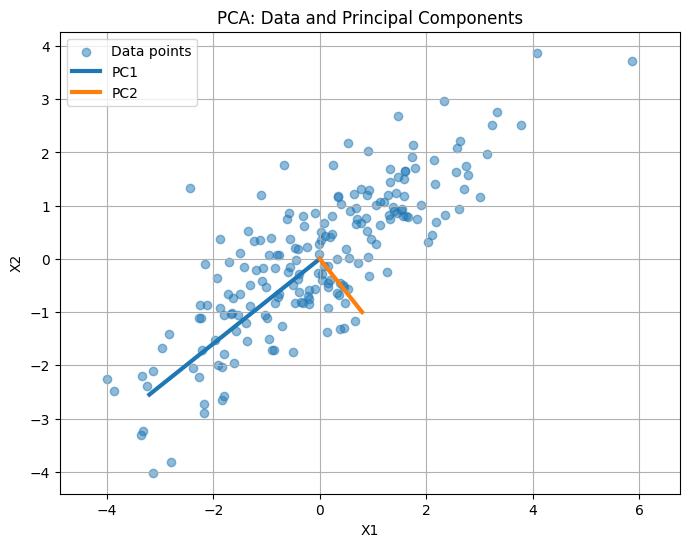

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic 2D data
np.random.seed(42)
mean = [0, 0]
cov = [[3, 2], [2, 2]]  # covariance matrix to introduce correlation
X = np.random.multivariate_normal(mean, cov, 200)

# PCA computation
X_centered = X - X.mean(axis=0)
cov_matrix = np.cov(X_centered, rowvar=False)
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)  # eigenvectors and eigenvalues
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# Plotting the data and principal components
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], alpha=0.5, label='Data points')

# Draw principal components
for i in range(2):
    vec = eigenvectors[:, i] * np.sqrt(eigenvalues[i]) * 2  # scale for visibility
    plt.plot([0, vec[0]], [0, vec[1]], lw=3, label=f'PC{i+1}')

plt.xlabel('X1')
plt.ylabel('X2')
plt.title('PCA: Data and Principal Components')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()


* The scatter plot shows the original 2D data points.
* The thick lines represent the **principal components (PC1 and PC2)**:

  * **PC1** points along the direction of maximum variance (longest spread of the data).
  * **PC2** is orthogonal to PC1 and captures the next largest variance.
* You can see how PCA “reorients” the axes to align with the data’s spread.

**Intuition:** Projecting the data onto these axes preserves most of the variance while reducing redundancy, which is the essence of PCA.
